<a href="https://colab.research.google.com/github/EvaCeryana/Hospital/blob/master/Sentiment_Based_Crypto_Trading_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving btc_1d_data_2018_to_2025.csv to btc_1d_data_2018_to_2025.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

In [4]:
file_name = "btc_1d_data_2018_to_2025.csv"

df = pd.read_csv(file_name)

df.head()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00.000000 UTC,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000 UTC,1.147997e+08,105595,3961.938946,5.280975e+07,0
1,2018-01-02 00:00:00.000000 UTC,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999000 UTC,2.797171e+08,177728,11346.326739,1.580801e+08,0
2,2018-01-03 00:00:00.000000 UTC,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999000 UTC,2.361169e+08,162787,8994.953566,1.335873e+08,0
3,2018-01-04 00:00:00.000000 UTC,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999000 UTC,3.127816e+08,170310,12680.812951,1.861168e+08,0
4,2018-01-05 00:00:00.000000 UTC,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999000 UTC,3.693220e+08,192969,13346.622293,2.118299e+08,0


In [5]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicated rows:")
print(df.duplicated().sum())

Dataset shape: (2997, 12)

Columns:
Index(['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'Ignore'],
      dtype='object')

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2997 entries, 0 to 2996
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Open time                     2997 non-null   object 
 1   Open                          2997 non-null   float64
 2   High                          2997 non-null   float64
 3   Low                           2997 non-null   float64
 4   Close                         2997 non-null   float64
 5   Volume                        2997 non-null   float64
 6   Close time                    2997 non-null   object 
 7   Quote asset volume            2997 non-null   float64
 8   Number of trades   

In [6]:
df.columns = df.columns.str.strip()

df = df.rename(columns={
    "Open time": "open_time",
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Close": "close",
    "Volume": "volume",
    "Close time": "close_time",
    "Quote asset volume": "quote_asset_volume",
    "Number of trades": "number_of_trades",
    "Taker buy base asset volume": "taker_buy_base_volume",
    "Taker buy quote asset volume": "taker_buy_quote_volume",
    "Ignore": "ignore"
})

df.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore
0,2018-01-01 00:00:00.000000 UTC,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000 UTC,1.147997e+08,105595,3961.938946,5.280975e+07,0
1,2018-01-02 00:00:00.000000 UTC,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999000 UTC,2.797171e+08,177728,11346.326739,1.580801e+08,0
2,2018-01-03 00:00:00.000000 UTC,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999000 UTC,2.361169e+08,162787,8994.953566,1.335873e+08,0
3,2018-01-04 00:00:00.000000 UTC,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999000 UTC,3.127816e+08,170310,12680.812951,1.861168e+08,0
4,2018-01-05 00:00:00.000000 UTC,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999000 UTC,3.693220e+08,192969,13346.622293,2.118299e+08,0


In [7]:
df["open_time"] = pd.to_datetime(df["open_time"].astype(str).str.replace(" UTC", ""), errors="coerce")
df["close_time"] = pd.to_datetime(df["close_time"].astype(str).str.replace(" UTC", ""), errors="coerce")

df = df.dropna(subset=["open_time"])

df = df.sort_values("open_time").reset_index(drop=True)

df.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore
0,2018-01-01,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999,1.147997e+08,105595,3961.938946,5.280975e+07,0
1,2018-01-02,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999,2.797171e+08,177728,11346.326739,1.580801e+08,0
2,2018-01-03,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999,2.361169e+08,162787,8994.953566,1.335873e+08,0
3,2018-01-04,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999,3.127816e+08,170310,12680.812951,1.861168e+08,0
4,2018-01-05,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999,3.693220e+08,192969,13346.622293,2.118299e+08,0


In [8]:
numeric_cols = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_base_volume",
    "taker_buy_quote_volume"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols] = df[numeric_cols].fillna(method="ffill")
df[numeric_cols] = df[numeric_cols].fillna(method="bfill")

print(df.isnull().sum())

open_time                 0
open                      0
high                      0
low                       0
close                     0
volume                    0
close_time                0
quote_asset_volume        0
number_of_trades          0
taker_buy_base_volume     0
taker_buy_quote_volume    0
ignore                    0
dtype: int64


/tmp/ipykernel_3762/1406695510.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[numeric_cols] = df[numeric_cols].fillna(method="ffill")
/tmp/ipykernel_3762/1406695510.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[numeric_cols] = df[numeric_cols].fillna(method="bfill")


In [9]:
if "ignore" in df.columns:
    df = df.drop(columns=["ignore"])

df.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume
0,2018-01-01,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999,1.147997e+08,105595,3961.938946,5.280975e+07
1,2018-01-02,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999,2.797171e+08,177728,11346.326739,1.580801e+08
2,2018-01-03,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999,2.361169e+08,162787,8994.953566,1.335873e+08
3,2018-01-04,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999,3.127816e+08,170310,12680.812951,1.861168e+08
4,2018-01-05,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999,3.693220e+08,192969,13346.622293,2.118299e+08


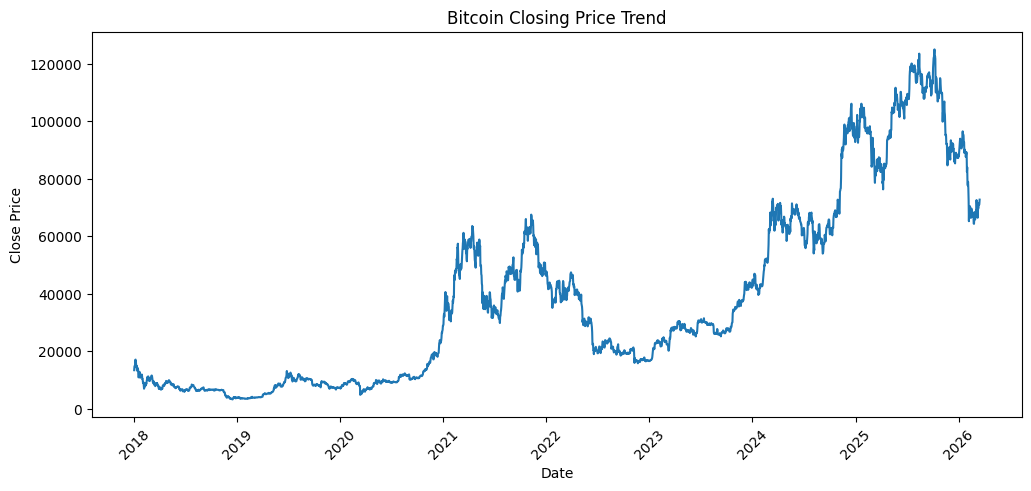

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(df["open_time"], df["close"])
plt.title("Bitcoin Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.show()

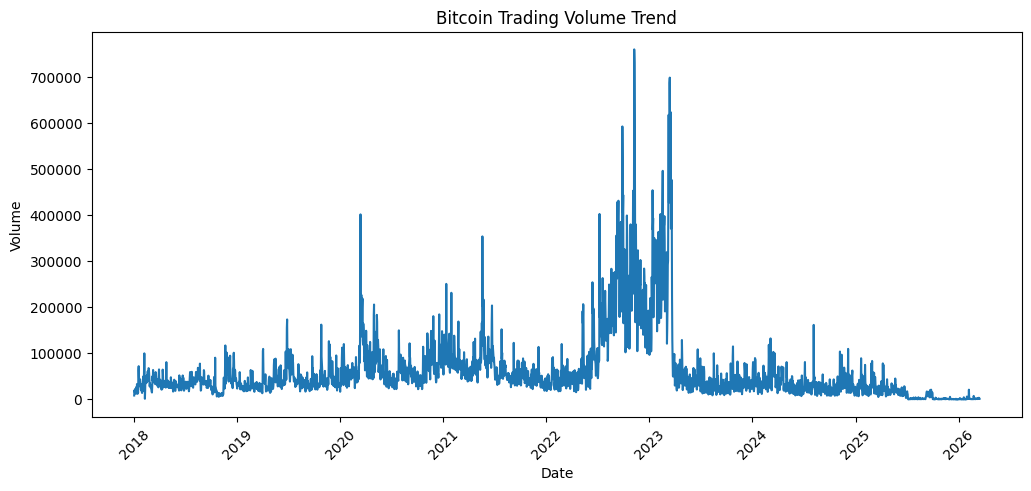

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(df["open_time"], df["volume"])
plt.title("Bitcoin Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.show()

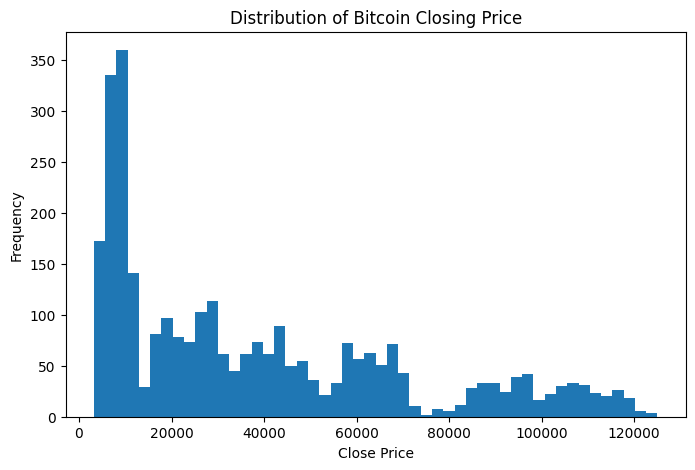

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df["close"], bins=50)
plt.title("Distribution of Bitcoin Closing Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

In [15]:
df["price_change"] = df["close"] - df["open"]

df["price_change_pct"] = ((df["close"] - df["open"]) / df["open"]) * 100

df["return"] = df["close"].pct_change()

df.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,price_change,price_change_pct,return
0,2018-01-01,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999,1.147997e+08,105595,3961.938946,5.280975e+07,-335.65,-2.447204,NaN
1,2018-01-02,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999,2.797171e+08,177728,11346.326739,1.580801e+08,1292.95,9.661744,0.096794
2,2018-01-03,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999,2.361169e+08,162787,8994.953566,1.335873e+08,229.51,1.562355,0.016654
3,2018-01-04,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999,3.127816e+08,170310,12680.812951,1.861168e+08,140.03,0.938570,0.009386
4,2018-01-05,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999,3.693220e+08,192969,13346.622293,2.118299e+08,1900.83,12.622082,0.126222


In [16]:
df["ma_7"] = df["close"].rolling(window=7).mean()
df["ma_14"] = df["close"].rolling(window=14).mean()
df["ma_30"] = df["close"].rolling(window=30).mean()

df["ma_7_gap"] = df["close"] - df["ma_7"]
df["ma_14_gap"] = df["close"] - df["ma_14"]
df["ma_30_gap"] = df["close"] - df["ma_30"]

df.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,price_change,price_change_pct,return,ma_7,ma_14,ma_30,ma_7_gap,ma_14_gap,ma_30_gap
0,2018-01-01,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999,1.147997e+08,105595,3961.938946,5.280975e+07,-335.65,-2.447204,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-02,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999,2.797171e+08,177728,11346.326739,1.580801e+08,1292.95,9.661744,0.096794,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-03,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999,2.361169e+08,162787,8994.953566,1.335873e+08,229.51,1.562355,0.016654,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-01-04,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999,3.127816e+08,170310,12680.812951,1.861168e+08,140.03,0.938570,0.009386,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-05,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999,3.693220e+08,192969,13346.622293,2.118299e+08,1900.83,12.622082,0.126222,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
df["volatility_7"] = df["return"].rolling(window=7).std()
df["volatility_14"] = df["return"].rolling(window=14).std()

df.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,...,price_change_pct,return,ma_7,ma_14,ma_30,ma_7_gap,ma_14_gap,ma_30_gap,volatility_7,volatility_14
0,2018-01-01,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999,1.147997e+08,105595,3961.938946,...,-2.447204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-02,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999,2.797171e+08,177728,11346.326739,...,9.661744,0.096794,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-03,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999,2.361169e+08,162787,8994.953566,...,1.562355,0.016654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-01-04,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999,3.127816e+08,170310,12680.812951,...,0.938570,0.009386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-05,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999,3.693220e+08,192969,13346.622293,...,12.622082,0.126222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df["volume_change"] = df["volume"].pct_change()

df["trade_intensity"] = df["number_of_trades"] / df["volume"]

df["trade_intensity"] = df["trade_intensity"].replace([np.inf, -np.inf], np.nan)

df.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,...,ma_7,ma_14,ma_30,ma_7_gap,ma_14_gap,ma_30_gap,volatility_7,volatility_14,volume_change,trade_intensity
0,2018-01-01,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999,1.147997e+08,105595,3961.938946,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.264348
1,2018-01-02,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999,2.797171e+08,177728,11346.326739,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.331973,8.851837
2,2018-01-03,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999,2.361169e+08,162787,8994.953566,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.207810,10.234528
3,2018-01-04,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999,3.127816e+08,170310,12680.812951,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.341009,7.984660
4,2018-01-05,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999,3.693220e+08,192969,13346.622293,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.090102,8.299210


In [19]:
def calculate_rsi(data, window=14):
    delta = data.diff()

    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss

    rsi = 100 - (100 / (1 + rs))

    return rsi

In [20]:
df["rsi_14"] = calculate_rsi(df["close"], window=14)

df[["close", "rsi_14"]].head(20)

,close,rsi_14
0,13380.00,NaN
1,14675.11,NaN
2,14919.51,NaN
3,15059.54,NaN
4,16960.39,NaN
5,17069.79,NaN
6,16150.03,NaN
7,14902.54,NaN
8,14400.00,NaN
9,14907.09,NaN


In [21]:
df["ema_12"] = df["close"].ewm(span=12, adjust=False).mean()
df["ema_26"] = df["close"].ewm(span=26, adjust=False).mean()

df["macd"] = df["ema_12"] - df["ema_26"]
df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
df["macd_hist"] = df["macd"] - df["macd_signal"]

df[["close", "macd", "macd_signal", "macd_hist"]].head()

,close,macd,macd_signal,macd_hist
0,13380.00,0.000000,0.000000,0.000000
1,14675.11,103.313618,20.662724,82.650895
2,14919.51,202.576269,57.045433,145.530837
3,15059.54,289.208076,103.477961,185.730114
4,16960.39,505.420937,183.866556,321.554381


In [23]:
df["taker_buy_ratio"] = df["taker_buy_base_volume"] / df["volume"]
df["taker_buy_ratio"] = df["taker_buy_ratio"].replace([np.inf, -np.inf], np.nan)

df["market_sentiment_score"] = (
    df["price_change_pct"] * 0.4 +
    df["taker_buy_ratio"] * 0.3 +
    df["macd_hist"] * 0.2 -
    df["volatility_7"] * 0.1
)

df.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,...,volume_change,trade_intensity,rsi_14,ema_12,ema_26,macd,macd_signal,macd_hist,taker_buy_ratio,market_sentiment_score
0,2018-01-01,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999,1.147997e+08,105595,3961.938946,...,NaN,12.264348,NaN,13380.000000,13380.000000,0.000000,0.000000,0.000000,0.460160,NaN
1,2018-01-02,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999,2.797171e+08,177728,11346.326739,...,1.331973,8.851837,NaN,13579.247692,13475.934074,103.313618,20.662724,82.650895,0.565110,NaN
2,2018-01-03,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999,2.361169e+08,162787,8994.953566,...,-0.207810,10.234528,NaN,13785.441893,13582.865624,202.576269,57.045433,145.530837,0.565519,NaN
3,2018-01-04,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999,3.127816e+08,170310,12680.812951,...,0.341009,7.984660,NaN,13981.456987,13692.248911,289.208076,103.477961,185.730114,0.594516,NaN
4,2018-01-05,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999,3.693220e+08,192969,13346.622293,...,0.090102,8.299210,NaN,14439.754373,13934.333436,505.420937,183.866556,321.554381,0.574011,NaN


In [24]:
def sentiment_label(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["market_sentiment_label"] = df["market_sentiment_score"].apply(sentiment_label)

df[["open_time", "close", "market_sentiment_score", "market_sentiment_label"]].head()

,open_time,close,market_sentiment_score,market_sentiment_label
0,2018-01-01,13380.00,NaN,Neutral
1,2018-01-02,14675.11,NaN,Neutral
2,2018-01-03,14919.51,NaN,Neutral
3,2018-01-04,15059.54,NaN,Neutral
4,2018-01-05,16960.39,NaN,Neutral


In [25]:
df["future_close"] = df["close"].shift(-1)

df["target"] = np.where(df["future_close"] > df["close"], 1, 0)

df[["open_time", "close", "future_close", "target"]].head()

,open_time,close,future_close,target
0,2018-01-01,13380.00,14675.11,1
1,2018-01-02,14675.11,14919.51,1
2,2018-01-03,14919.51,15059.54,1
3,2018-01-04,15059.54,16960.39,1
4,2018-01-05,16960.39,17069.79,1


In [26]:
df = df.dropna().reset_index(drop=True)

print(df.shape)
print(df.isnull().sum())

(2967, 35)
open_time                 0
open                      0
high                      0
low                       0
close                     0
volume                    0
close_time                0
quote_asset_volume        0
number_of_trades          0
taker_buy_base_volume     0
taker_buy_quote_volume    0
price_change              0
price_change_pct          0
return                    0
ma_7                      0
ma_14                     0
ma_30                     0
ma_7_gap                  0
ma_14_gap                 0
ma_30_gap                 0
volatility_7              0
volatility_14             0
volume_change             0
trade_intensity           0
rsi_14                    0
ema_12                    0
ema_26                    0
macd                      0
macd_signal               0
macd_hist                 0
taker_buy_ratio           0
market_sentiment_score    0
market_sentiment_label    0
future_close              0
target                    0
dtype: in

In [27]:
features = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_base_volume",
    "taker_buy_quote_volume",
    "price_change_pct",
    "return",
    "ma_7",
    "ma_14",
    "ma_30",
    "ma_7_gap",
    "ma_14_gap",
    "ma_30_gap",
    "volatility_7",
    "volatility_14",
    "volume_change",
    "trade_intensity",
    "rsi_14",
    "macd",
    "macd_signal",
    "macd_hist",
    "taker_buy_ratio",
    "market_sentiment_score"
]

X = df[features]
y = df["target"]

print(X.shape)
print(y.shape)

(2967, 27)
(2967,)


In [28]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (2373, 27)
Testing size: (594, 27)


In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.49158249158249157
              precision    recall  f1-score   support

           0       0.33      0.01      0.03       298
           1       0.49      0.97      0.66       296

    accuracy                           0.49       594
   macro avg       0.41      0.49      0.34       594
weighted avg       0.41      0.49      0.34       594



In [31]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=8
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.5151515151515151
              precision    recall  f1-score   support

           0       0.51      0.86      0.64       298
           1       0.54      0.17      0.26       296

    accuracy                           0.52       594
   macro avg       0.53      0.51      0.45       594
weighted avg       0.53      0.52      0.45       594



In [32]:
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

Gradient Boosting Accuracy: 0.531986531986532
              precision    recall  f1-score   support

           0       0.52      0.71      0.61       298
           1       0.55      0.35      0.43       296

    accuracy                           0.53       594
   macro avg       0.54      0.53      0.52       594
weighted avg       0.54      0.53      0.52       594



In [33]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.491582
1,Random Forest,0.515152
2,Gradient Boosting,0.531987


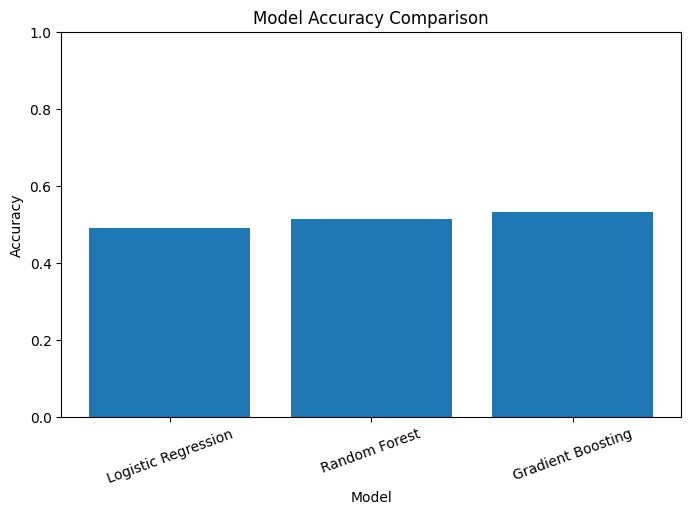

In [34]:
plt.figure(figsize=(8, 5))
plt.bar(model_results["Model"], model_results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

In [35]:
best_model = rf_model

df["predicted_direction"] = best_model.predict(X)

df[["open_time", "close", "target", "predicted_direction"]].head()

,open_time,close,target,predicted_direction
0,2018-01-30,10237.51,1,1
1,2018-01-31,10285.10,0,0
2,2018-02-01,9224.52,0,0
3,2018-02-02,8873.03,1,1
4,2018-02-03,9199.96,0,0


In [36]:
def generate_signal(row):
    if row["predicted_direction"] == 1 and row["market_sentiment_score"] > 0:
        return "BUY"
    elif row["predicted_direction"] == 0 and row["market_sentiment_score"] < 0:
        return "SELL"
    else:
        return "HOLD"

df["trading_signal"] = df.apply(generate_signal, axis=1)

df[["open_time", "close", "market_sentiment_score", "predicted_direction", "trading_signal"]].head(20)

,open_time,close,market_sentiment_score,predicted_direction,trading_signal
0,2018-01-30,10237.51,-13.014432,1,HOLD
1,2018-01-31,10285.10,-13.108101,0,SELL
2,2018-02-01,9224.52,-31.476354,0,SELL
3,2018-02-02,8873.03,-39.373488,1,HOLD
4,2018-02-03,9199.96,-35.362521,0,SELL
5,2018-02-04,8184.81,-50.153713,0,SELL
6,2018-02-05,6939.99,-69.236962,1,HOLD
7,2018-02-06,7652.14,-55.833849,0,SELL
8,2018-02-07,7599.00,-53.848805,1,HOLD
9,2018-02-08,7784.02,-41.373473,1,HOLD


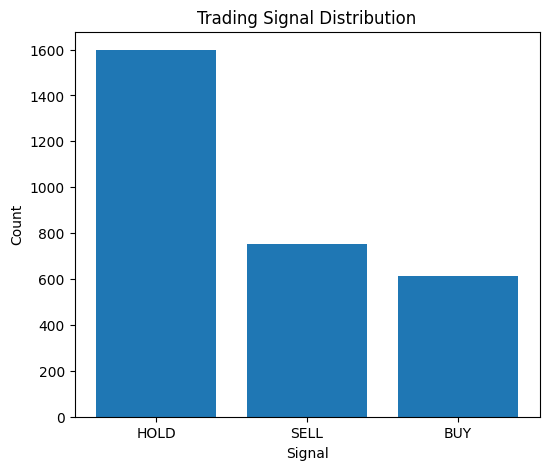

In [37]:
signal_counts = df["trading_signal"].value_counts()

signal_counts
plt.figure(figsize=(6, 5))
plt.bar(signal_counts.index, signal_counts.values)
plt.title("Trading Signal Distribution")
plt.xlabel("Signal")
plt.ylabel("Count")
plt.show()

In [38]:
initial_balance = 10000
balance = initial_balance
btc_holdings = 0

portfolio_values = []

for i in range(len(df)):
    price = df.loc[i, "close"]
    signal = df.loc[i, "trading_signal"]

    if signal == "BUY" and balance > 0:
        btc_holdings = balance / price
        balance = 0

    elif signal == "SELL" and btc_holdings > 0:
        balance = btc_holdings * price
        btc_holdings = 0

    portfolio_value = balance + btc_holdings * price
    portfolio_values.append(portfolio_value)

df["portfolio_value"] = portfolio_values

final_value = df["portfolio_value"].iloc[-1]
profit = final_value - initial_balance
profit_pct = (profit / initial_balance) * 100

print("Initial Balance:", initial_balance)
print("Final Portfolio Value:", final_value)
print("Profit:", profit)
print("Profit Percentage:", profit_pct)

Initial Balance: 10000
Final Portfolio Value: 2586663.381243935
Profit: 2576663.381243935
Profit Percentage: 25766.633812439348


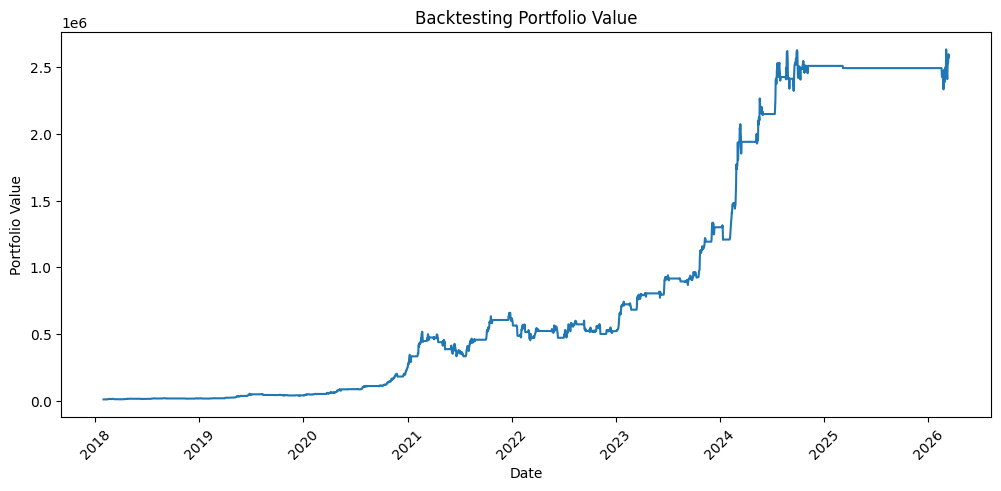

In [39]:
plt.figure(figsize=(12, 5))
plt.plot(df["open_time"], df["portfolio_value"])
plt.title("Backtesting Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.xticks(rotation=45)
plt.show()

In [40]:
buy_hold_btc = initial_balance / df["close"].iloc[0]
df["buy_hold_value"] = buy_hold_btc * df["close"]

final_buy_hold = df["buy_hold_value"].iloc[-1]
buy_hold_profit = final_buy_hold - initial_balance
buy_hold_profit_pct = (buy_hold_profit / initial_balance) * 100

print("Buy and Hold Final Value:", final_buy_hold)
print("Buy and Hold Profit:", buy_hold_profit)
print("Buy and Hold Profit Percentage:", buy_hold_profit_pct)

Buy and Hold Final Value: 69597.66583866584
Buy and Hold Profit: 59597.66583866584
Buy and Hold Profit Percentage: 595.9766583866584


In [41]:
buy_hold_btc = initial_balance / df["close"].iloc[0]
df["buy_hold_value"] = buy_hold_btc * df["close"]

final_buy_hold = df["buy_hold_value"].iloc[-1]
buy_hold_profit = final_buy_hold - initial_balance
buy_hold_profit_pct = (buy_hold_profit / initial_balance) * 100

print("Buy and Hold Final Value:", final_buy_hold)
print("Buy and Hold Profit:", buy_hold_profit)
print("Buy and Hold Profit Percentage:", buy_hold_profit_pct)

Buy and Hold Final Value: 69597.66583866584
Buy and Hold Profit: 59597.66583866584
Buy and Hold Profit Percentage: 595.9766583866584


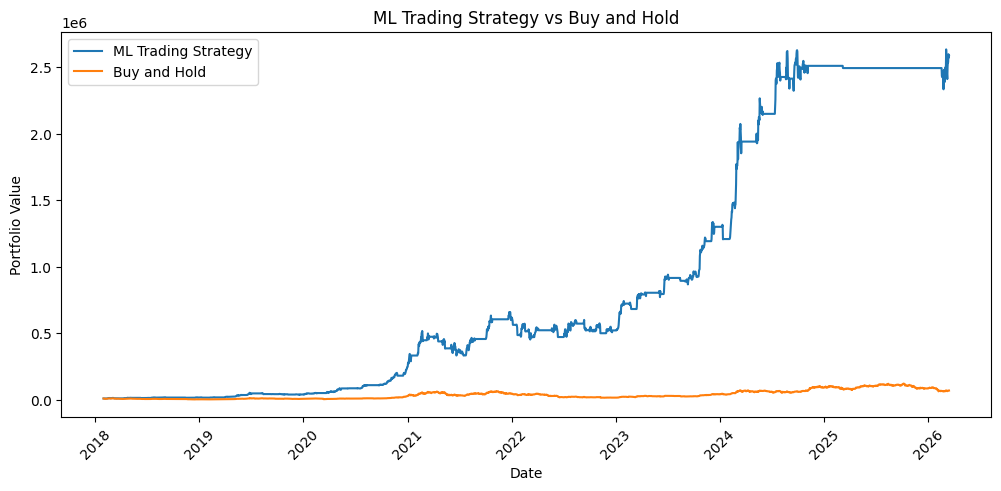

In [42]:
plt.figure(figsize=(12, 5))
plt.plot(df["open_time"], df["portfolio_value"], label="ML Trading Strategy")
plt.plot(df["open_time"], df["buy_hold_value"], label="Buy and Hold")
plt.title("ML Trading Strategy vs Buy and Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [43]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
10,return,0.062728
9,price_change_pct,0.060086
21,rsi_14,0.046995
25,taker_buy_ratio,0.046892
14,ma_7_gap,0.044183
18,volatility_14,0.043987
19,volume_change,0.041769
17,volatility_7,0.041535
24,macd_hist,0.040908
15,ma_14_gap,0.036945


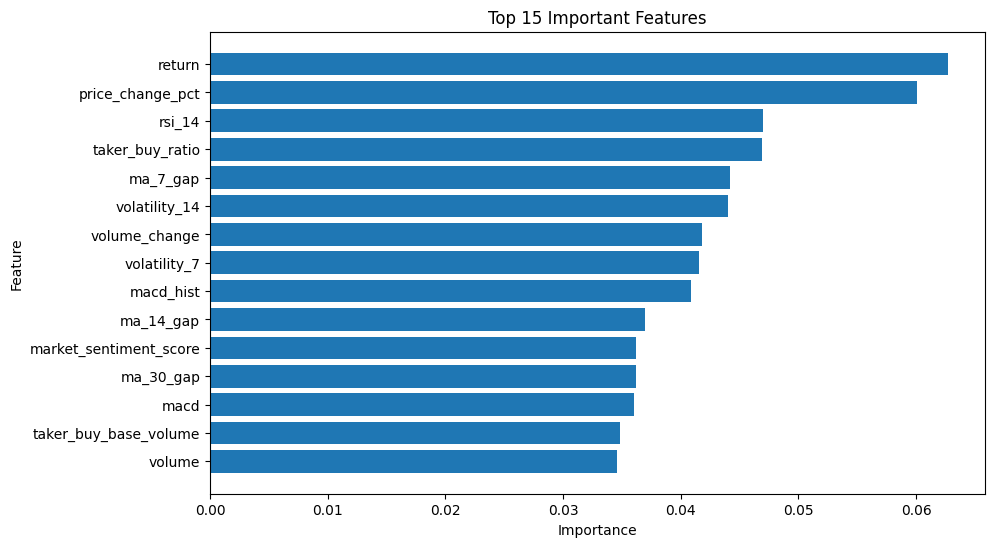

In [44]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"].head(15), feature_importance["Importance"].head(15))
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

[[256  42]
 [246  50]]


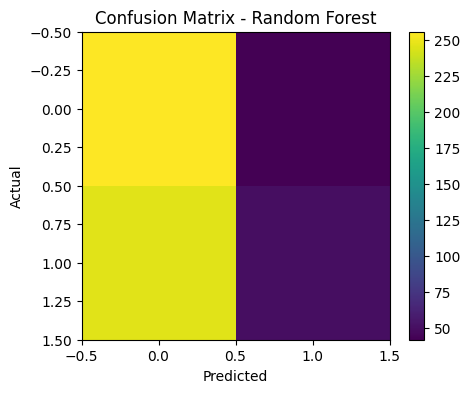

In [45]:
cm = confusion_matrix(y_test, rf_pred)

print(cm)
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [46]:
final_result = df[[
    "open_time",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "market_sentiment_score",
    "market_sentiment_label",
    "target",
    "predicted_direction",
    "trading_signal",
    "portfolio_value",
    "buy_hold_value"
]]

final_result.head()

,open_time,open,high,low,close,volume,market_sentiment_score,market_sentiment_label,target,predicted_direction,trading_signal,portfolio_value,buy_hold_value
0,2018-01-30,11250.11,11308.42,9900.00,10237.51,25554.372946,-13.014432,Negative,1,1,HOLD,10000.0,10000.000000
1,2018-01-31,10230.00,10425.85,9700.00,10285.10,18015.956805,-13.108101,Negative,0,0,SELL,10000.0,10046.485913
2,2018-02-01,10285.10,10335.00,8750.99,9224.52,33564.764311,-31.476354,Negative,0,0,SELL,10000.0,9010.511345
3,2018-02-02,9224.52,9250.00,8010.02,8873.03,49971.626975,-39.373488,Negative,1,1,HOLD,10000.0,8667.175905
4,2018-02-03,8873.03,9473.01,8229.00,9199.96,28725.000735,-35.362521,Negative,0,0,SELL,10000.0,8986.521136
